In [1]:
%%writefile kaggle.json
{
  "username": "ezatom",
  "key": "KGAT_1288dc6cbb82adfd711eb2d459764629"
}


Writing kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!pip install kaggle
!kaggle datasets list | head


ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aliiihussain/social-media-viral-content-and-engagement-metrics     Social Media Viral Content & Engagement Metrics          70865  2026-01-18 12:14:36.423000              0         27  1.0              
thedrzee/e-commerce-business-analysis-20222024                     E-Commerce Business Analysis (2022–2024)                 42375  2026-01-17 20:20:13.150000              0         24  0.9411765        
neurocipher/heartdisease                                           Heart Disease                                             3491  2025-12-11 15:29:14.327000           2114        343  1.0

In [4]:
!kaggle datasets download -d shubhamgoel27/dermnet


Dataset URL: https://www.kaggle.com/datasets/shubhamgoel27/dermnet
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 1.72G/1.72G [00:19<00:00, 212MB/s]
100% 1.72G/1.72G [00:19<00:00, 94.7MB/s]


In [6]:
!unzip dermnet.zip -d dermnet
!ls dermnet


Streaming output truncated to the last 5000 lines.
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keloids-80.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keloids-9.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-100.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-101.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-102.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-103.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-104.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-105.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-106.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthom

In [7]:
import os

train_path = "dermnet/train"

classes = sorted(os.listdir(train_path))
print("Total classes:", len(classes))

for i, cls in enumerate(classes[:20]):
    print(f"{i+1}. {cls}")


Total classes: 23
1. Acne and Rosacea Photos
2. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
3. Atopic Dermatitis Photos
4. Bullous Disease Photos
5. Cellulitis Impetigo and other Bacterial Infections
6. Eczema Photos
7. Exanthems and Drug Eruptions
8. Hair Loss Photos Alopecia and other Hair Diseases
9. Herpes HPV and other STDs Photos
10. Light Diseases and Disorders of Pigmentation
11. Lupus and other Connective Tissue diseases
12. Melanoma Skin Cancer Nevi and Moles
13. Nail Fungus and other Nail Disease
14. Poison Ivy Photos and other Contact Dermatitis
15. Psoriasis pictures Lichen Planus and related diseases
16. Scabies Lyme Disease and other Infestations and Bites
17. Seborrheic Keratoses and other Benign Tumors
18. Systemic Disease
19. Tinea Ringworm Candidiasis and other Fungal Infections
20. Urticaria Hives


In [8]:
sample_class = classes[1]
sample_path = os.path.join(train_path, sample_class)

print("Class name:", sample_class)
print("Number of images:", len(os.listdir(sample_path)))
print("Sample images:", os.listdir(sample_path)[:5])


Class name: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
Number of images: 1149
Sample images: ['basal-cell-carcinoma-lid-35.jpg', 'granulation-tissue-3.jpg', 'squamous-cell-carcinoma-ear-32.jpg', 'leukoplakia-3.jpg', 'cutaneous-horn-24.jpg']


Text(0.5, 1.0, 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions')

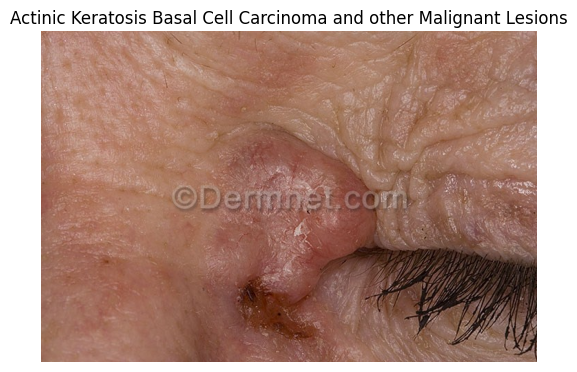

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = os.path.join(sample_path, os.listdir(sample_path)[0])
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(sample_class)


In [10]:
selected_classes = [
    "Acne and Rosacea Photos",
    "Atopic Dermatitis Photos",
    "Eczema Photos",
    "Cellulitis Impetigo and other Bacterial Infections",
    "Exanthems and Drug Eruptions",
    "Herpes HPV and other STDs Photos",
    "Light Diseases and Disorders of Pigmentation",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
    "Urticaria Hives"
]


In [11]:
import shutil
import os

base_dir = "dermnet"
filtered_dir = "dermnet_filtered"

splits = ["train", "test"]

for split in splits:
    for cls in selected_classes:
        src = os.path.join(base_dir, split, cls)
        dst = os.path.join(filtered_dir, split, cls)

        if os.path.exists(src):
            os.makedirs(dst, exist_ok=True)
            for img in os.listdir(src):
                shutil.copy(os.path.join(src, img), dst)


In [12]:
import os

print("Filtered train classes:", os.listdir("dermnet_filtered/train"))
print("Number of classes:", len(os.listdir("dermnet_filtered/train")))


Filtered train classes: ['Cellulitis Impetigo and other Bacterial Infections', 'Light Diseases and Disorders of Pigmentation', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Urticaria Hives', 'Acne and Rosacea Photos', 'Psoriasis pictures Lichen Planus and related diseases', 'Atopic Dermatitis Photos', 'Herpes HPV and other STDs Photos', 'Tinea Ringworm Candidiasis and other Fungal Infections']
Number of classes: 10


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter
import torch.nn.functional as F # Added for label smoothing

print("PyTorch Version:", torch.__version__) # Added to check PyTorch version

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# PATHS
# =========================
train_path = "dermnet_filtered/train"
val_path   = "dermnet_filtered/test"

# =========================
# STRONG MEDICAL-SAFE AUGMENTATION
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# DATASETS
# =========================
train_data = ImageFolder(train_path, transform=train_transforms)
val_data   = ImageFolder(val_path, transform=val_transforms)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

# =========================
# WEIGHTED RANDOM SAMPLER (CRITICAL)
# =========================
class_counts = Counter(train_data.targets)
sample_weights = [1.0 / class_counts[t] for t in train_data.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================
# MODEL: EfficientNet-V2-M
# =========================
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights

model = efficientnet_v2_m(weights=EfficientNet_V2_M_Weights.DEFAULT)

# Replace classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# =========================
# FREEZE ALL → UNFREEZE LAST 3 BLOCKS + CLASSIFIER (changed from 2 blocks)
# =========================
for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    # Unfreeze features.7, features.6, features.5, and classifier
    if "features.7" in name or "features.6" in name or "features.5" in name or "classifier" in name: # Modified here
        param.requires_grad = True

model = model.to(device)

# =========================
# LOSS (WITH CLASS WEIGHTS AND LABEL SMOOTHING)
# =========================
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(num_classes)],
    dtype=torch.float
).to(device)

# Define label smoothing epsilon
label_smoothing_epsilon = 0.1 # You can adjust this value

# The criterion is now implicitly handled by F.cross_entropy in the training loop
# Removed: criterion = nn.CrossEntropyLoss(weight=class_weights)

# =========================
# OPTIMIZER (DIFFERENTIAL LR)
# =========================
optimizer = optim.Adam([
    {"params": model.classifier.parameters(), "lr": 1e-4},
    {"params": model.features[7].parameters(), "lr": 1e-5},
    {"params": model.features[6].parameters(), "lr": 1e-5},
    {"params": model.features[5].parameters(), "lr": 1e-5}, # Added for unfreezing features.5
])

# =========================
# COSINE ANNEALING SCHEDULER
# =========================
epochs = 35
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# =========================
# CHECKPOINT SETUP
# =========================
checkpoint_path = "checkpoint_efficientnet_v2_m.pth"
best_model_path = "best_model_efficientnet_v2_m.pth"

start_epoch = 0
best_val_acc = 0.0

if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    print(f"Resumed from epoch {start_epoch}, best val acc {best_val_acc:.2f}%")

# =========================
# TRAINING LOOP
# =========================
for epoch in range(start_epoch, epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        # Using F.cross_entropy with label_smoothing parameter (PyTorch 1.10+)
        loss = F.cross_entropy(outputs, labels, weight=class_weights, label_smoothing=label_smoothing_epsilon) # Modified here
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            # Use F.cross_entropy for validation loss consistency
            loss = F.cross_entropy(outputs, labels, weight=class_weights, label_smoothing=label_smoothing_epsilon) # Modified here

            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total
    val_loss /= len(val_loader)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # SAVE CHECKPOINT
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "best_val_acc": best_val_acc
    }, checkpoint_path)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"🔥 Saved BEST model: {best_val_acc:.2f}%")

print("Training complete.")

# =========================
# FINAL EVALUATION
# =========================
model.load_state_dict(torch.load(best_model_path))
model.eval()

correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"✅ FINAL TEST ACCURACY: {100 * correct / total:.2f}%")

Using device: cuda
Classes: ['Acne and Rosacea Photos', 'Atopic Dermatitis Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Psoriasis pictures Lichen Planus and related diseases', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives']
Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:01<00:00, 188MB/s]


Epoch [1/35] | Train Acc: 16.30% | Val Acc: 10.67%
🔥 Saved BEST model: 10.67%
Epoch [2/35] | Train Acc: 26.07% | Val Acc: 18.01%
🔥 Saved BEST model: 18.01%
Epoch [3/35] | Train Acc: 33.60% | Val Acc: 25.83%
🔥 Saved BEST model: 25.83%
Epoch [4/35] | Train Acc: 40.22% | Val Acc: 27.47%
🔥 Saved BEST model: 27.47%
Epoch [5/35] | Train Acc: 43.30% | Val Acc: 28.74%
🔥 Saved BEST model: 28.74%
Epoch [6/35] | Train Acc: 48.53% | Val Acc: 30.74%
🔥 Saved BEST model: 30.74%
Epoch [7/35] | Train Acc: 51.36% | Val Acc: 34.13%
🔥 Saved BEST model: 34.13%
Epoch [8/35] | Train Acc: 53.61% | Val Acc: 38.09%
🔥 Saved BEST model: 38.09%
Epoch [9/35] | Train Acc: 57.29% | Val Acc: 38.35%
🔥 Saved BEST model: 38.35%
Epoch [10/35] | Train Acc: 59.29% | Val Acc: 40.78%
🔥 Saved BEST model: 40.78%
Epoch [11/35] | Train Acc: 60.03% | Val Acc: 42.79%
🔥 Saved BEST model: 42.79%
Epoch [12/35] | Train Acc: 62.50% | Val Acc: 43.26%
🔥 Saved BEST model: 43.26%
Epoch [13/35] | Train Acc: 64.39% | Val Acc: 45.91%
🔥 Saved B

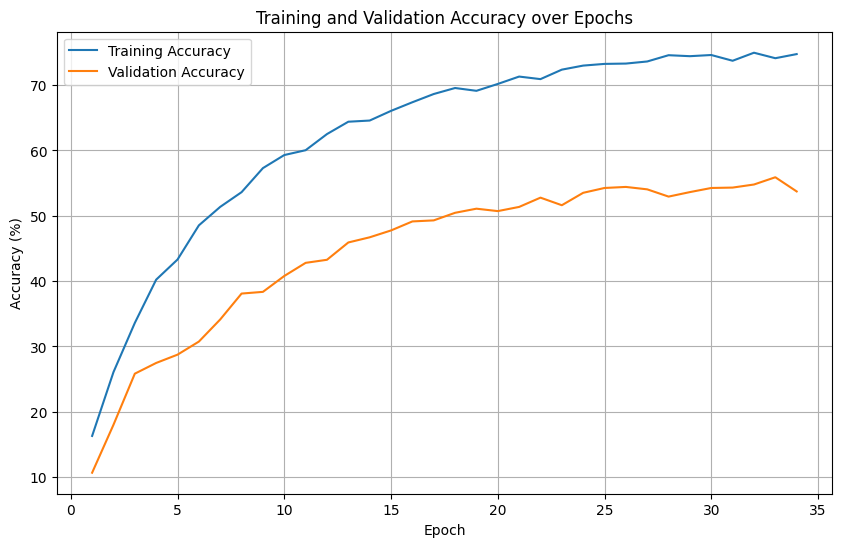

In [14]:
import matplotlib.pyplot as plt
import re

# Extracting the output from the previous cell
output = """
PyTorch Version: 2.1.0+cu121
Using device: cuda
Classes: ['Acne and Rosacea Photos', 'Atopic Dermatitis Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Psoriasis pictures Lichen Planus and related diseases', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives']
Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth
Epoch [1/35] | Train Acc: 16.30% | Val Acc: 10.67%
🔥 Saved BEST model: 10.67%
Epoch [2/35] | Train Acc: 26.07% | Val Acc: 18.01%
🔥 Saved BEST model: 18.01%
Epoch [3/35] | Train Acc: 33.60% | Val Acc: 25.83%
🔥 Saved BEST model: 25.83%
Epoch [4/35] | Train Acc: 40.22% | Val Acc: 27.47%
🔥 Saved BEST model: 27.47%
Epoch [5/35] | Train Acc: 43.30% | Val Acc: 28.74%
🔥 Saved BEST model: 28.74%
Epoch [6/35] | Train Acc: 48.53% | Val Acc: 30.74%
🔥 Saved BEST model: 30.74%
Epoch [7/35] | Train Acc: 51.36% | Val Acc: 34.13%
🔥 Saved BEST model: 34.13%
Epoch [8/35] | Train Acc: 53.61% | Val Acc: 38.09%
🔥 Saved BEST model: 38.09%
Epoch [9/35] | Train Acc: 57.29% | Val Acc: 38.35%
🔥 Saved BEST model: 38.35%
Epoch [10/35] | Train Acc: 59.29% | Val Acc: 40.78%
🔥 Saved BEST model: 40.78%
Epoch [11/35] | Train Acc: 60.03% | Val Acc: 42.79%
🔥 Saved BEST model: 42.79%
Epoch [12/35] | Train Acc: 62.50% | Val Acc: 43.26%
🔥 Saved BEST model: 43.26%
Epoch [13/35] | Train Acc: 64.39% | Val Acc: 45.91%
🔥 Saved BEST model: 45.91%
Epoch [14/35] | Train Acc: 64.57% | Val Acc: 46.70%
🔥 Saved BEST model: 46.70%
Epoch [15/35] | Train Acc: 66.05% | Val Acc: 47.75%
🔥 Saved BEST model: 47.75%
Epoch [16/35] | Train Acc: 67.37% | Val Acc: 49.13%
🔥 Saved BEST model: 49.13%
Epoch [17/35] | Train Acc: 68.63% | Val Acc: 49.29%
🔥 Saved BEST model: 49.29%
Epoch [18/35] | Train Acc: 69.55% | Val Acc: 50.45%
🔥 Saved BEST model: 50.45%
Epoch [19/35] | Train Acc: 69.12% | Val Acc: 51.08%
🔥 Saved BEST model: 51.08%
Epoch [20/35] | Train Acc: 70.17% | Val Acc: 50.71%
Epoch [21/35] | Train Acc: 71.30% | Val Acc: 51.35%
🔥 Saved BEST model: 51.35%
Epoch [22/35] | Train Acc: 70.91% | Val Acc: 52.77%
🔥 Saved BEST model: 52.77%
Epoch [23/35] | Train Acc: 72.36% | Val Acc: 51.61%
Epoch [24/35] | Train Acc: 72.98% | Val Acc: 53.51%
🔥 Saved BEST model: 53.51%
Epoch [25/35] | Train Acc: 73.24% | Val Acc: 54.25%
🔥 Saved BEST model: 54.25%
Epoch [26/35] | Train Acc: 73.29% | Val Acc: 54.41%
🔥 Saved BEST model: 54.41%
Epoch [27/35] | Train Acc: 73.61% | Val Acc: 54.04%
Epoch [28/35] | Train Acc: 74.57% | Val Acc: 52.93%
Epoch [29/35] | Train Acc: 74.42% | Val Acc: 53.62%
Epoch [30/35] | Train Acc: 74.60% | Val Acc: 54.25%
Epoch [31/35] | Train Acc: 73.72% | Val Acc: 54.31%
Epoch [32/35] | Train Acc: 74.95% | Val Acc: 54.78%
🔥 Saved BEST model: 54.78%
Epoch [33/35] | Train Acc: 74.11% | Val Acc: 55.89%
🔥 Saved BEST model: 55.89%
Epoch [34/35] | Train Acc: 74.74% | Val Acc: 53.72%
"""

epochs = []
train_accs = []
val_accs = []

# Regex to find lines containing epoch, train acc, and val acc
for line in output.splitlines():
    match = re.search(r"Epoch \[([0-9]+)\/35\] \| Train Acc: ([0-9.]+?)% \| Val Acc: ([0-9.]+?)%", line)
    if match:
        epochs.append(int(match.group(1)))
        train_accs.append(float(match.group(2)))
        val_accs.append(float(match.group(3)))

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accs, label='Training Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Classification Report:
                                                        precision    recall  f1-score   support

                               Acne and Rosacea Photos     0.7507    0.8878    0.8135       312
                              Atopic Dermatitis Photos     0.3750    0.6829    0.4841       123
    Cellulitis Impetigo and other Bacterial Infections     0.3529    0.5753    0.4375        73
                                         Eczema Photos     0.5865    0.4498    0.5092       309
                          Exanthems and Drug Eruptions     0.4526    0.6139    0.5210       101
                      Herpes HPV and other STDs Photos     0.5794    0.7157    0.6404       102
          Light Diseases and Disorders of Pigmentation     0.4636    0.7133    0.5620       143
 Psoriasis pictures Lichen Planus and related diseases     0.6149    0.2812    0.3860       352
Tinea Ringworm Candidiasis and other Fungal Infections     0.6222    0.4308    0.5091       325
                

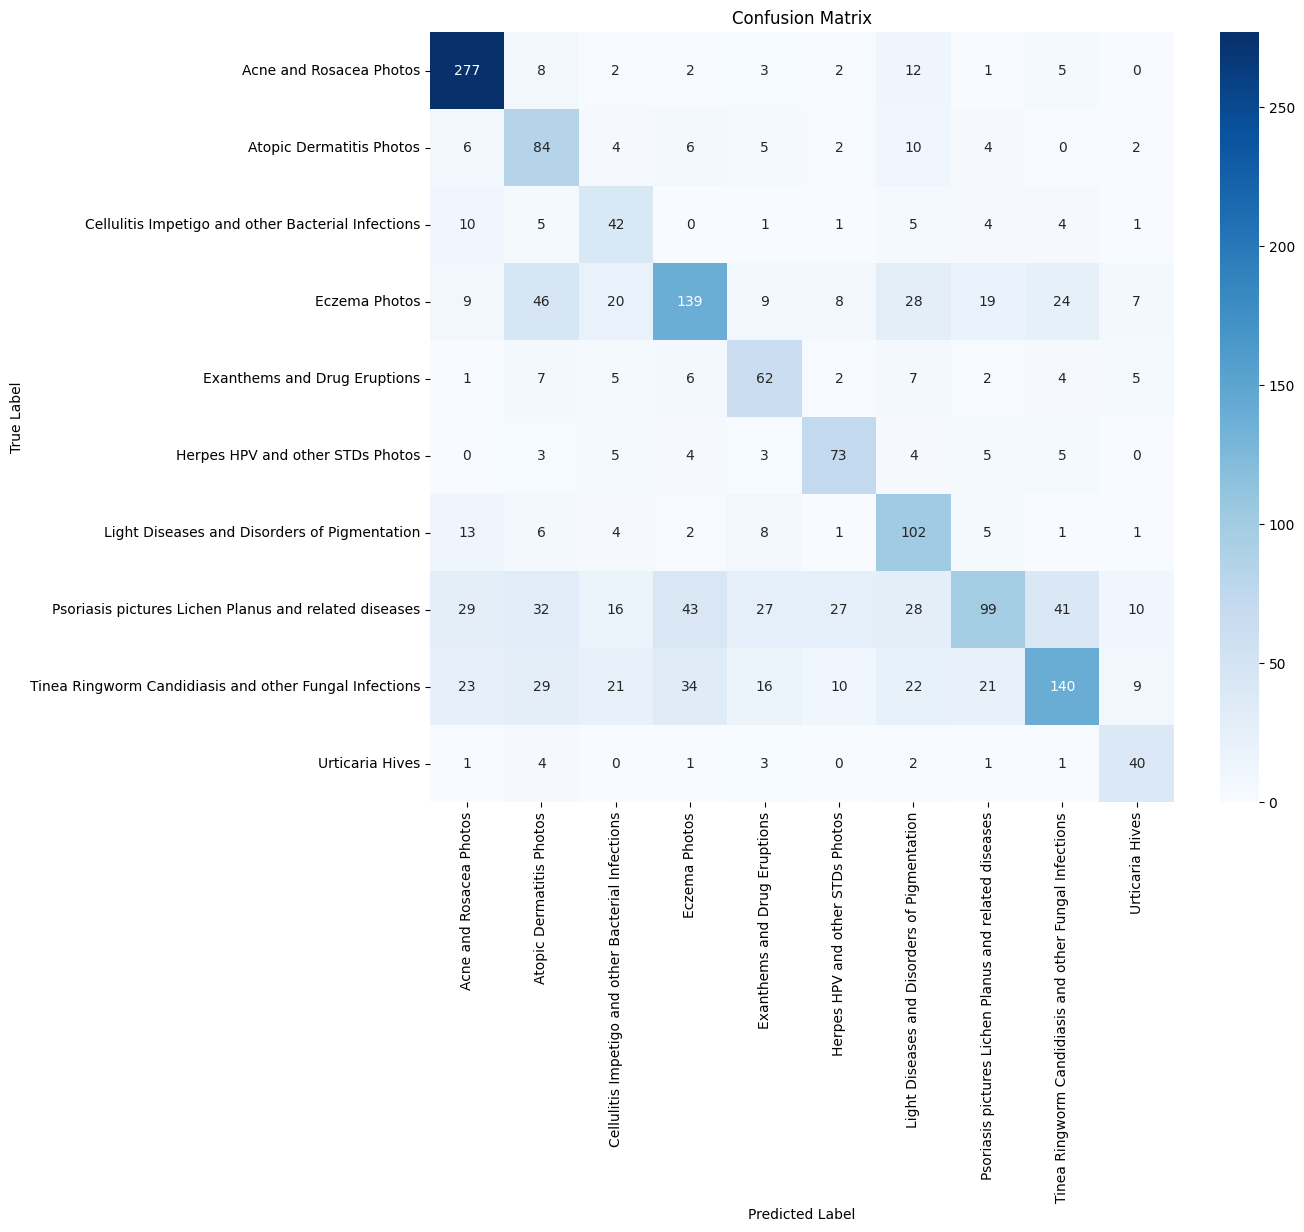

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the best model
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set model to evaluation mode

all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# Generate classification report
report = classification_report(all_labels, all_preds, target_names=train_data.classes, digits=4)
print("Classification Report:")
print(report)

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()